Project analyse de données

In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

In [2]:
songs = pd.read_csv("archive/spotify_songs.csv")
songs.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
#
print(songs.describe())

       track_popularity  danceability        energy           key  \
count      32833.000000  32833.000000  32833.000000  32833.000000   
mean          42.477081      0.654850      0.698619      5.374471   
std           24.984074      0.145085      0.180910      3.611657   
min            0.000000      0.000000      0.000175      0.000000   
25%           24.000000      0.563000      0.581000      2.000000   
50%           45.000000      0.672000      0.721000      6.000000   
75%           62.000000      0.761000      0.840000      9.000000   
max          100.000000      0.983000      1.000000     11.000000   

           loudness          mode   speechiness  acousticness  \
count  32833.000000  32833.000000  32833.000000  32833.000000   
mean      -6.719499      0.565711      0.107068      0.175334   
std        2.988436      0.495671      0.101314      0.219633   
min      -46.448000      0.000000      0.000000      0.000000   
25%       -8.171000      0.000000      0.041000      

In [ ]:
categorical_cols = [
    "playlist_name", 
    "playlist_genre", 
    "playlist_subgenre",
    "mode",
    "key"
]

for col in categorical_cols:
    songs[col] = pd.Categorical(songs[col], ordered=False)

songs.describe()

,track_popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,-6.719499,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,2.988436,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,-8.171000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,-6.166000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,-4.645000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,1.275000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [5]:
print('=== Checking ===')
songs.dropna(inplace=True)
print(songs.isnull().sum())

=== Checking ===
track_id                    0
track_name                  0
track_artist                0
track_popularity            0
track_album_id              0
track_album_name            0
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


In [6]:
print(songs[categorical_cols].describe())

          playlist_name playlist_genre          playlist_subgenre   mode  \
count             32828          32828                      32828  32828   
unique              449              6                         24      2   
top     Indie Poptimism            edm  progressive electro house      1   
freq                308           6043                       1809  18572   

          key  
count   32828  
unique     12  
top         1  
freq     4010  


In [7]:
songs.drop(columns=["track_album_release_date","track_artist","track_album_name","track_id","track_name","track_album_id","playlist_id","playlist_name"],inplace=True)


In [8]:
songs.dtypes
print(songs.head())

   track_popularity playlist_genre playlist_subgenre  danceability  energy  \
0                66            pop         dance pop         0.748   0.916   
1                67            pop         dance pop         0.726   0.815   
2                70            pop         dance pop         0.675   0.931   
3                60            pop         dance pop         0.718   0.930   
4                69            pop         dance pop         0.650   0.833   

  key  loudness mode  speechiness  acousticness  instrumentalness  liveness  \
0   6    -2.634    1       0.0583        0.1020          0.000000    0.0653   
1  11    -4.969    1       0.0373        0.0724          0.004210    0.3570   
2   1    -3.432    0       0.0742        0.0794          0.000023    0.1100   
3   7    -3.778    1       0.1020        0.0287          0.000009    0.2040   
4   1    -4.672    1       0.0359        0.0803          0.000000    0.0833   

   valence    tempo  duration_ms  
0    0.518  122.036  

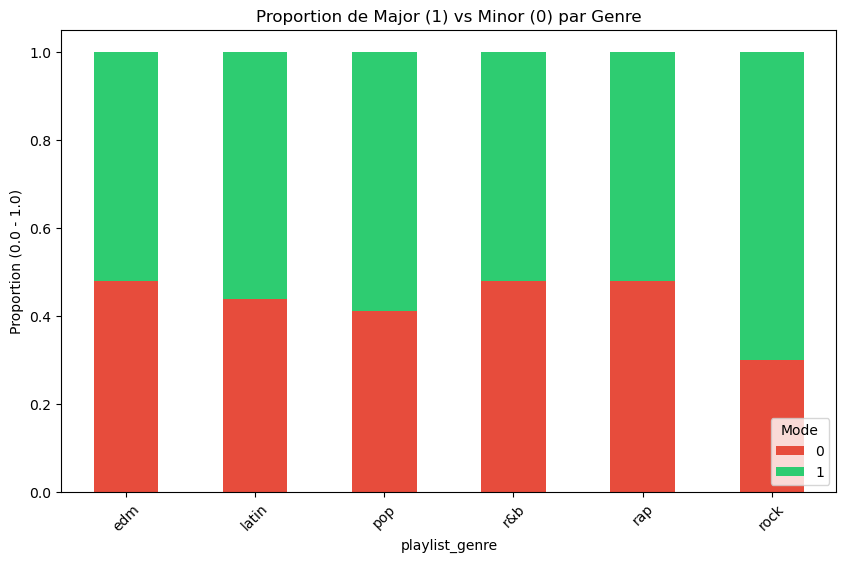

In [9]:
prop_table = pd.crosstab(songs['playlist_genre'], songs['mode'], normalize='index')

prop_table.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#e74c3c', '#2ecc71'])
plt.title("Proportion de Major (1) vs Minor (0) par Genre")
plt.ylabel("Proportion (0.0 - 1.0)")
plt.legend(title="Mode", loc='lower right')
plt.xticks(rotation=45)
plt.show()

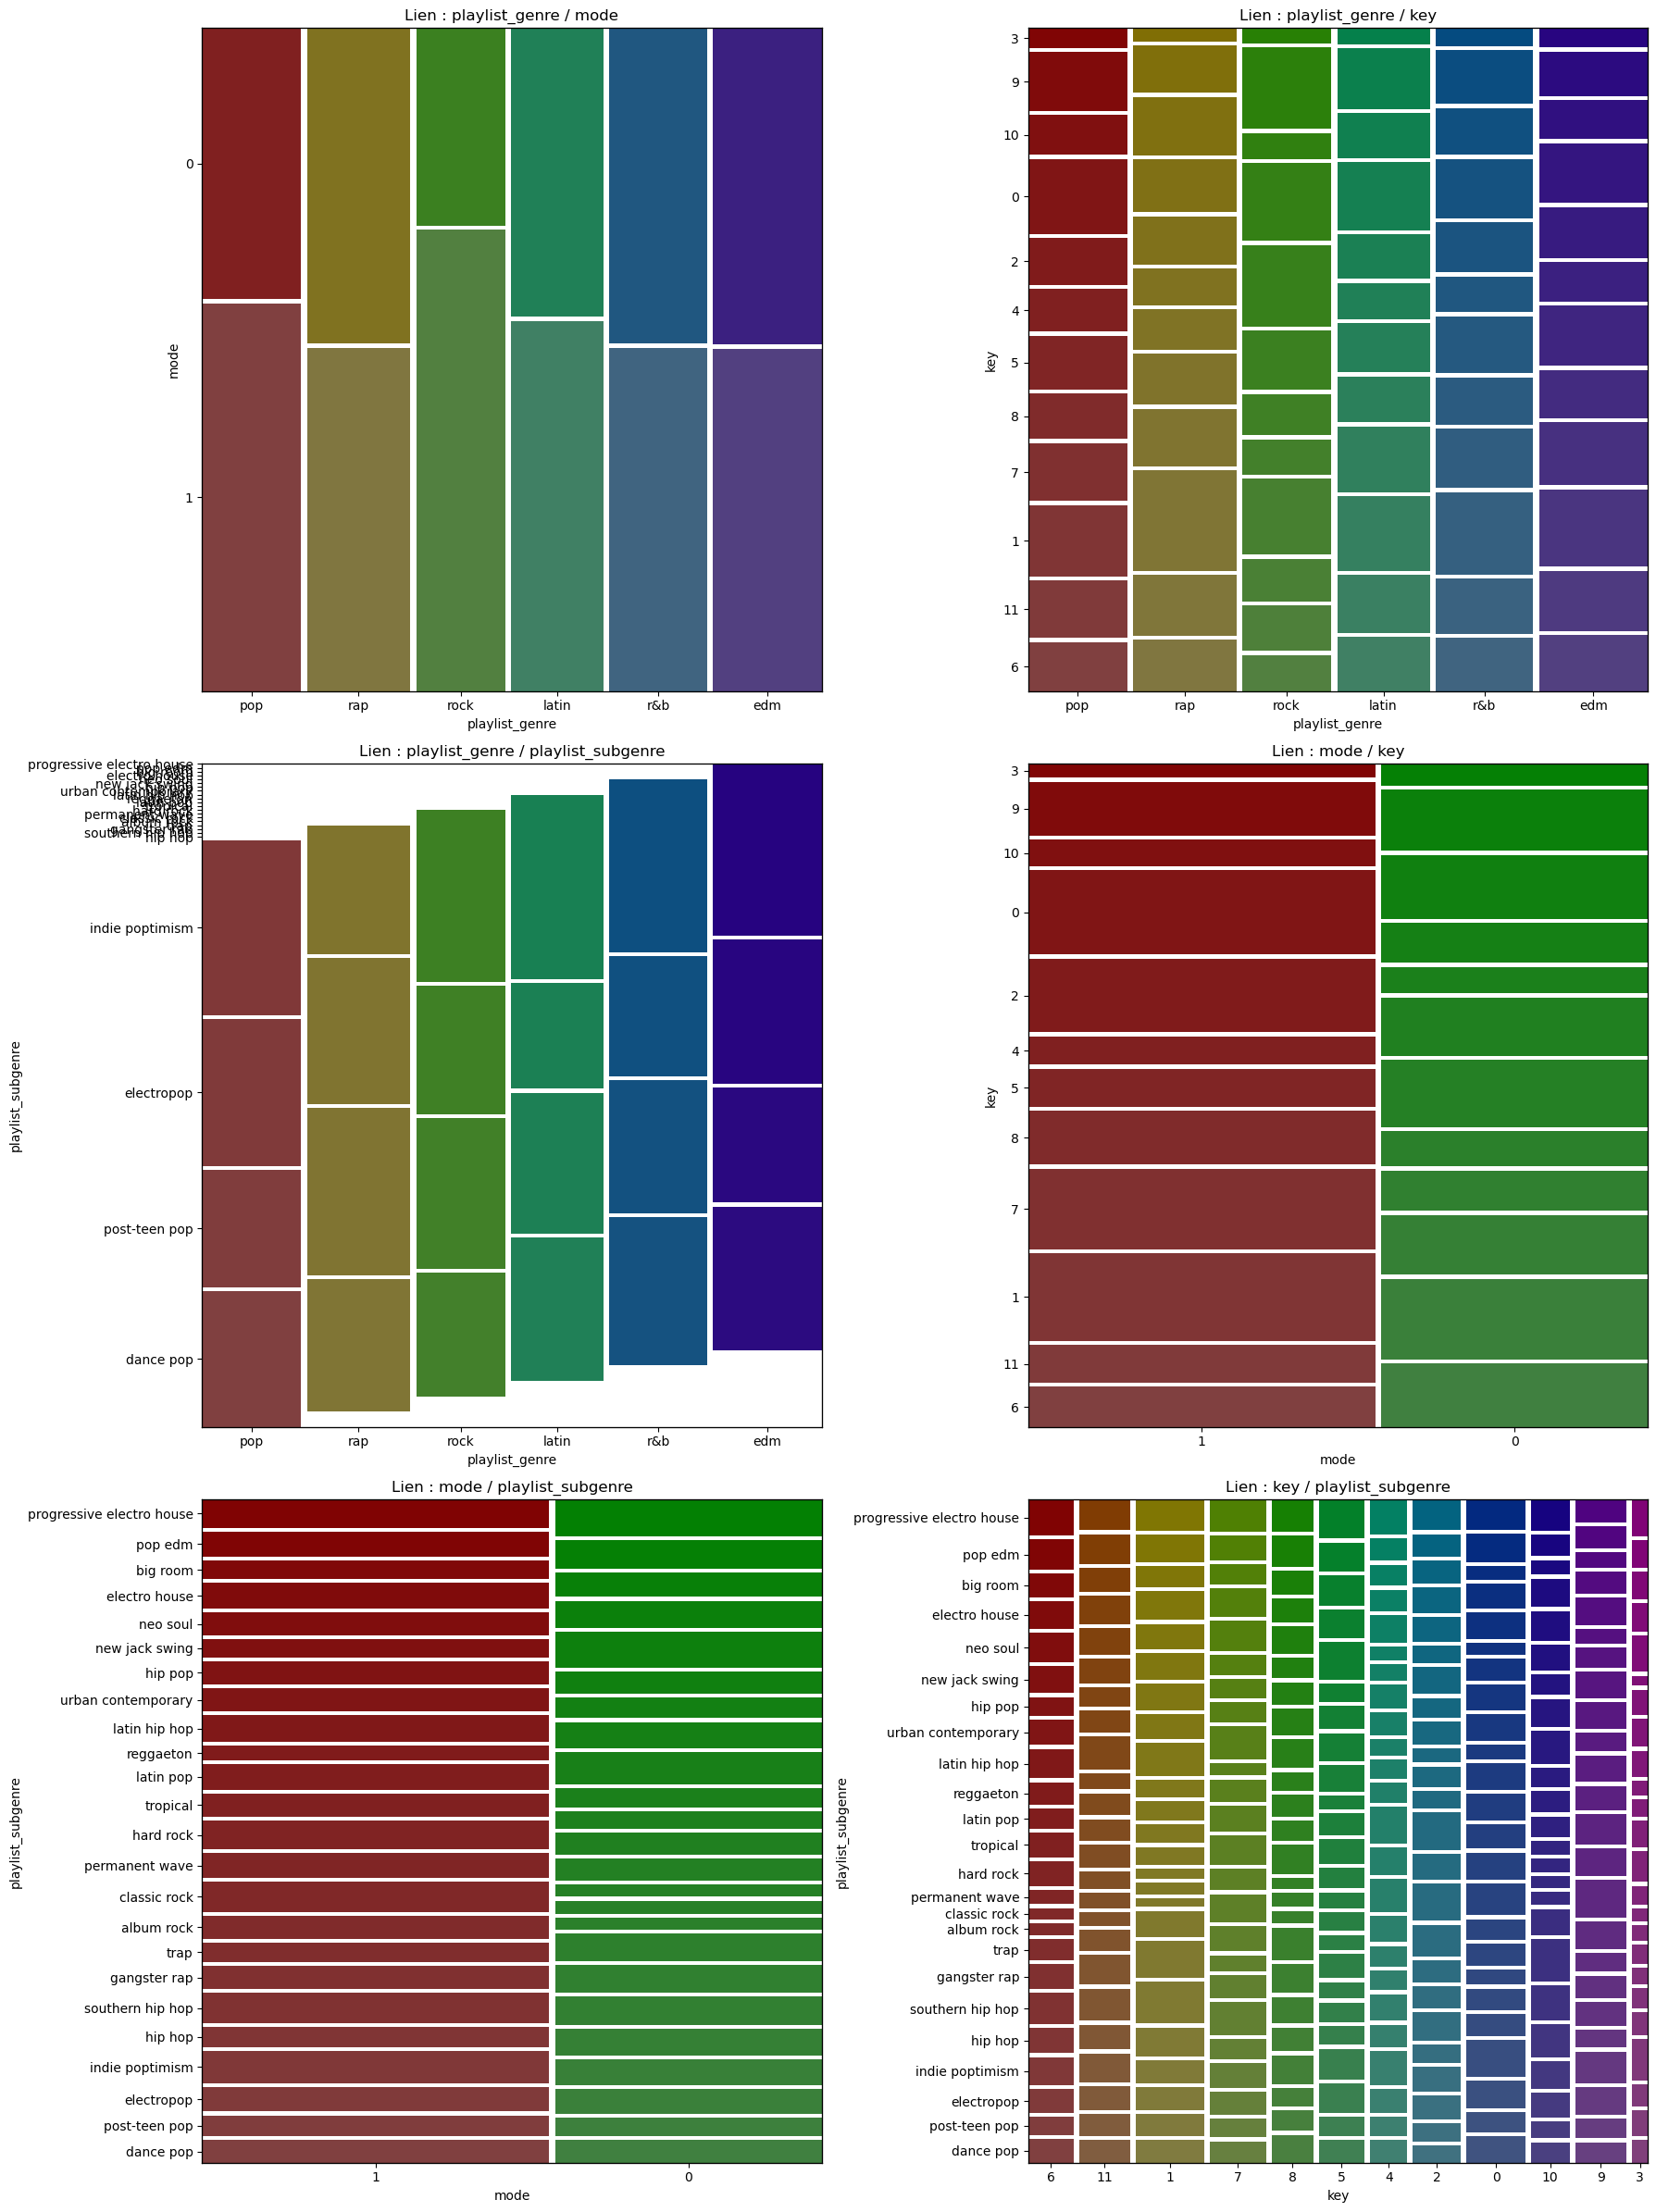

In [10]:
# 1. Liste des variables catégorielles à croiser
import itertools
# On évite 'track_artist' ou 'playlist_name' car trop de modalités (illisibles)
cols_to_compare = ["playlist_genre", "mode", "key", "playlist_subgenre"]

# 2. Création de toutes les combinaisons possibles de couples (2 parmi N)
couples = list(itertools.combinations(cols_to_compare, 2))

# 3. Configuration de la grille
n_cols = 2
n_rows = (len(couples) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8 * n_rows))
axes = axes.flatten()

# 4. Boucle de génération des Mosaic Plots
for i, (var_x, var_y) in enumerate(couples):
    # On crée le dictionnaire de données pour le mosaic plot
    mosaic(songs, [var_x, var_y], 
           ax=axes[i], 
           title=f"Lien : {var_x} / {var_y}",
           labelizer=lambda k: "", # Supprime le texte interne pour la clarté
           gap=0.01) # Petit espace entre les rectangles
    
    axes[i].set_ylabel(var_y)
    axes[i].set_xlabel(var_x)

# 5. Nettoyage des graphiques vides
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
# 1. Préparer les données (compter les combinaisons Genre -> Subgenre)

import plotly.graph_objects as go
counts = songs.groupby(['playlist_genre', 'playlist_subgenre']).size().reset_index(name='count')

# 2. Créer la liste unique des labels (Genres + Sous-genres)
all_nodes = list(counts['playlist_genre'].unique()) + list(counts['playlist_subgenre'].unique())
node_indices = {name: i for i, name in enumerate(all_nodes)}

# 3. Définir les sources (genres), les cibles (sous-genres) et les valeurs (comptes)
source = counts['playlist_genre'].map(node_indices)
target = counts['playlist_subgenre'].map(node_indices)
value = counts['count']

# 4. Créer la figure
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = all_nodes,
      color = "skyblue"
    ),
    link = dict(
      source = source,
      target = target,
      value = value,
      color = "rgba(135, 206, 235, 0.4)" # Bleu transparent pour les flux
  ))])

fig.update_layout(title_text="Flux des Genres vers les Sous-genres", font_size=12)
fig.show()

/tmp/ipykernel_4903/2149578505.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = songs.groupby(['playlist_genre', 'playlist_subgenre']).size().reset_index(name='count')


In [12]:
print(songs.columns)
quant_cols = songs.select_dtypes(include=['float64', 'int64']).columns
#quant_cols = quant_cols.drop(["duration_ms"])

Index(['track_popularity', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')


/tmp/ipykernel_4903/1238622242.py:6: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



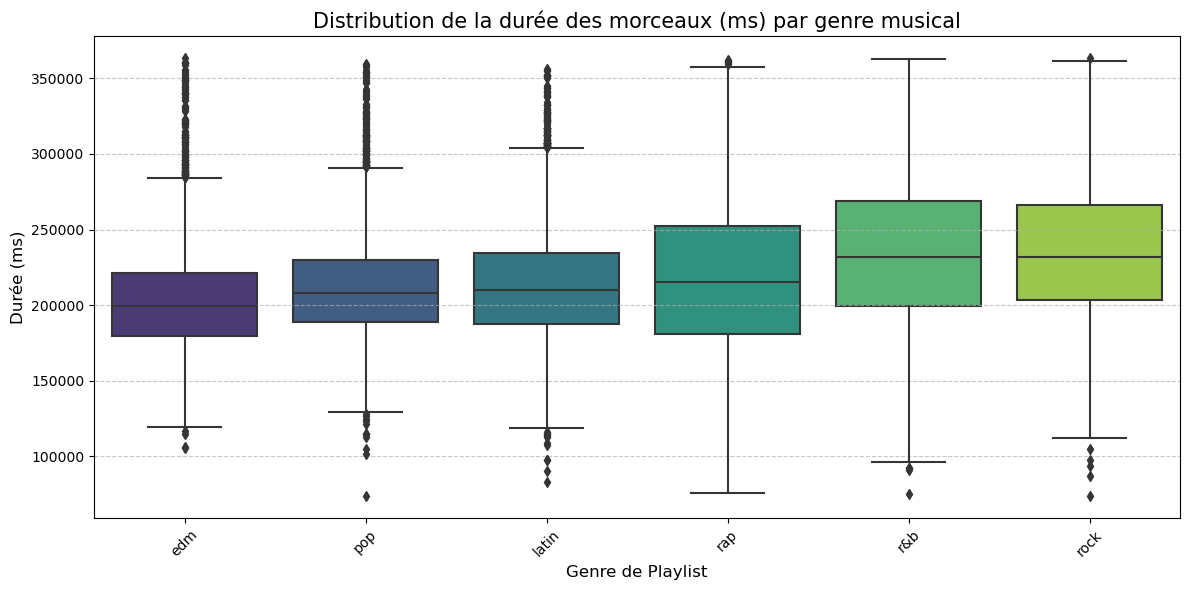

In [73]:
# 1. Configuration de la taille du graphique
plt.figure(figsize=(12, 6))

# 2. Création du Boxplot
# On trie par médiane pour plus de clarté visuelle
order = songs.groupby('playlist_genre')['duration_ms'].median().sort_values().index

sns.boxplot(
    x='playlist_genre', 
    y='duration_ms', 
    data=songs, 
    order=order,
    palette='viridis'
)

# 3. Personnalisation
plt.title('Distribution de la durée des morceaux (ms) par genre musical', fontsize=15)
plt.xlabel('Genre de Playlist', fontsize=12)
plt.ylabel('Durée (ms)', fontsize=12)
plt.xticks(rotation=45) # Rotation des noms pour éviter qu'ils se chevauchent
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Supression des données

In [13]:
# 2. Appliquer le filtre des outliers
print(f"Nombre de lignes avant suppression des outliers : {len(songs)}")
for col in quant_cols:
    Q1 = songs[col].quantile(0.25)
    Q3 = songs[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.96 * IQR
    upper_bound = Q3 + 1.96 * IQR
    
    # On ne garde que les données dans l'intervalle
    songs = songs[(songs[col] >= lower_bound) & (songs[col] <= upper_bound)]

# 3. Vérification du résultat
print(f"Nombre de lignes après suppression des outliers : {len(songs)}")

Nombre de lignes avant suppression des outliers : 32828
Nombre de lignes après suppression des outliers : 21589


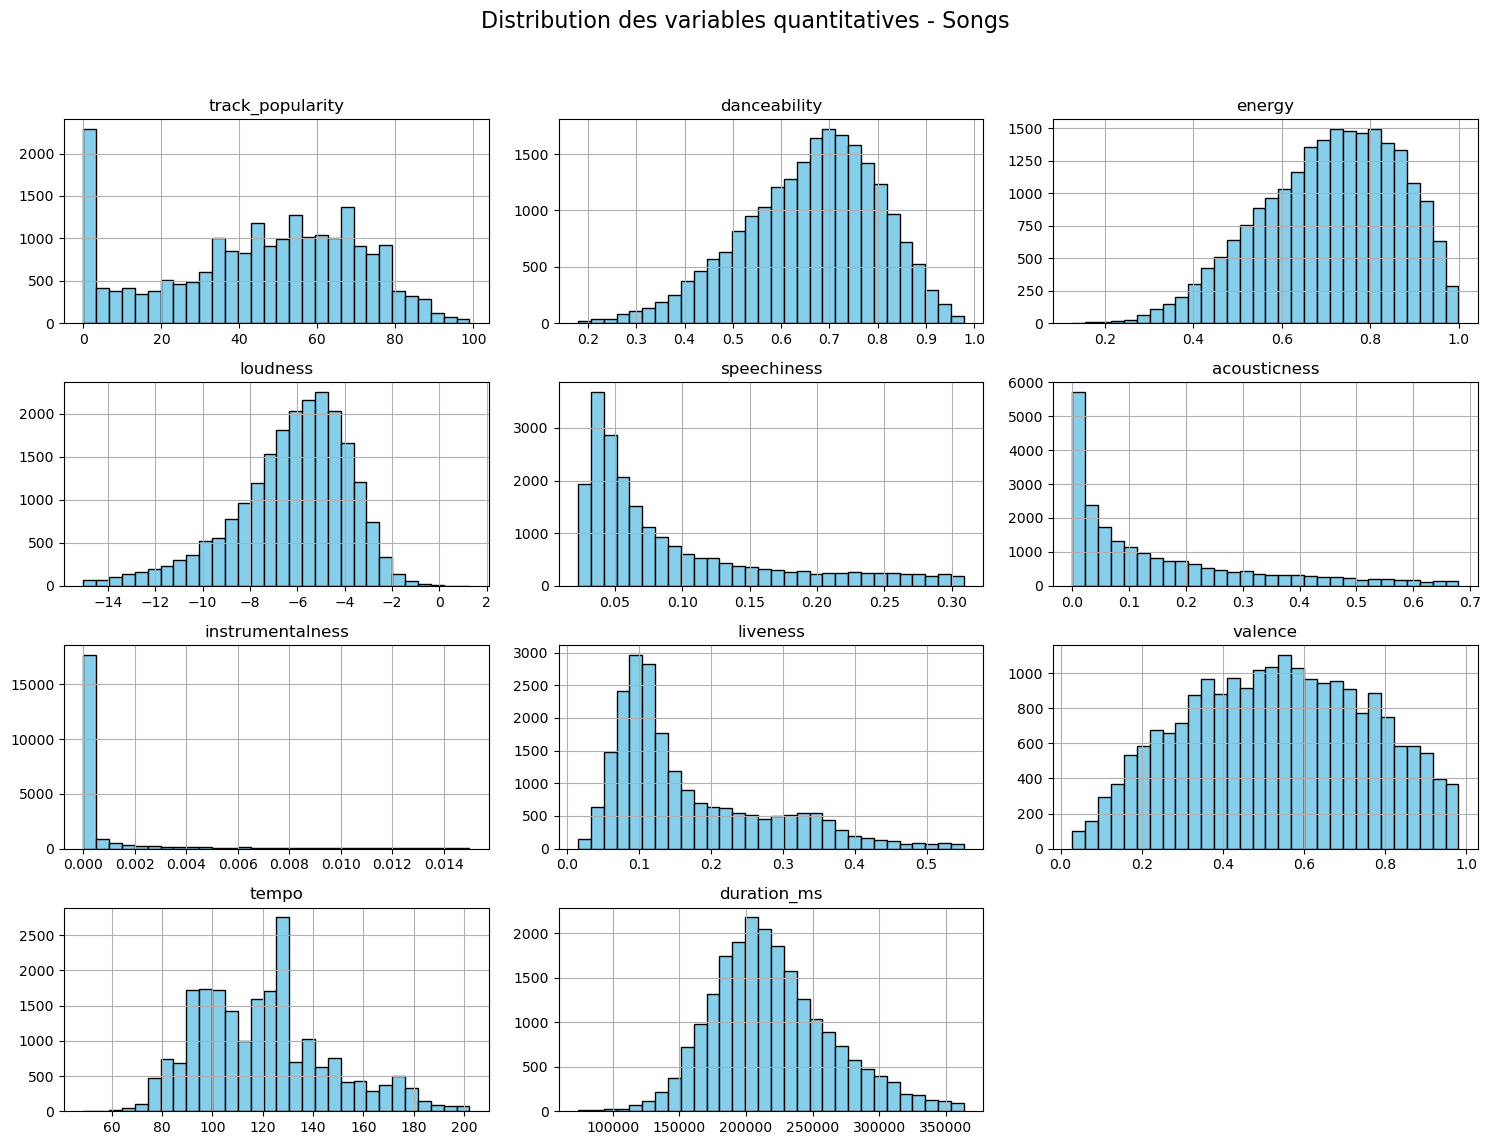

In [14]:

# 2. Tracer les histogrammes
songs[quant_cols].hist(bins=30, figsize=(15, 12), color='skyblue', edgecolor='black')

# 3. Ajuster l'affichage pour éviter le chevauchement
plt.suptitle("Distribution des variables quantitatives - Songs", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

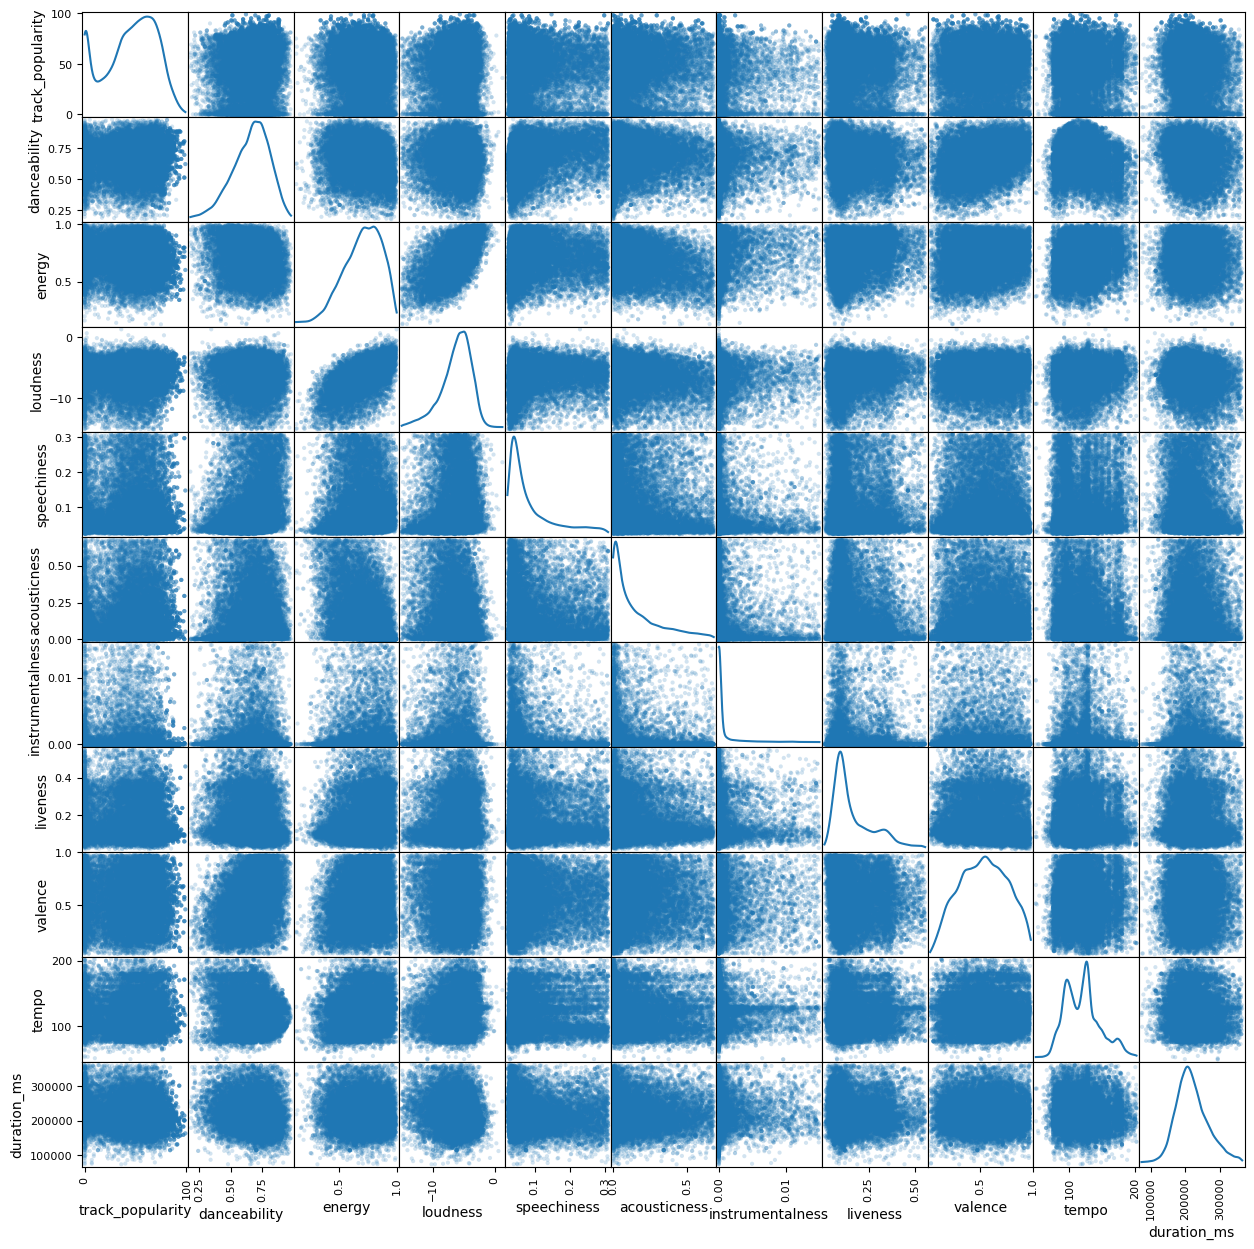

In [15]:
from pandas.plotting import scatter_matrix
scatter_matrix(songs, alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.show()

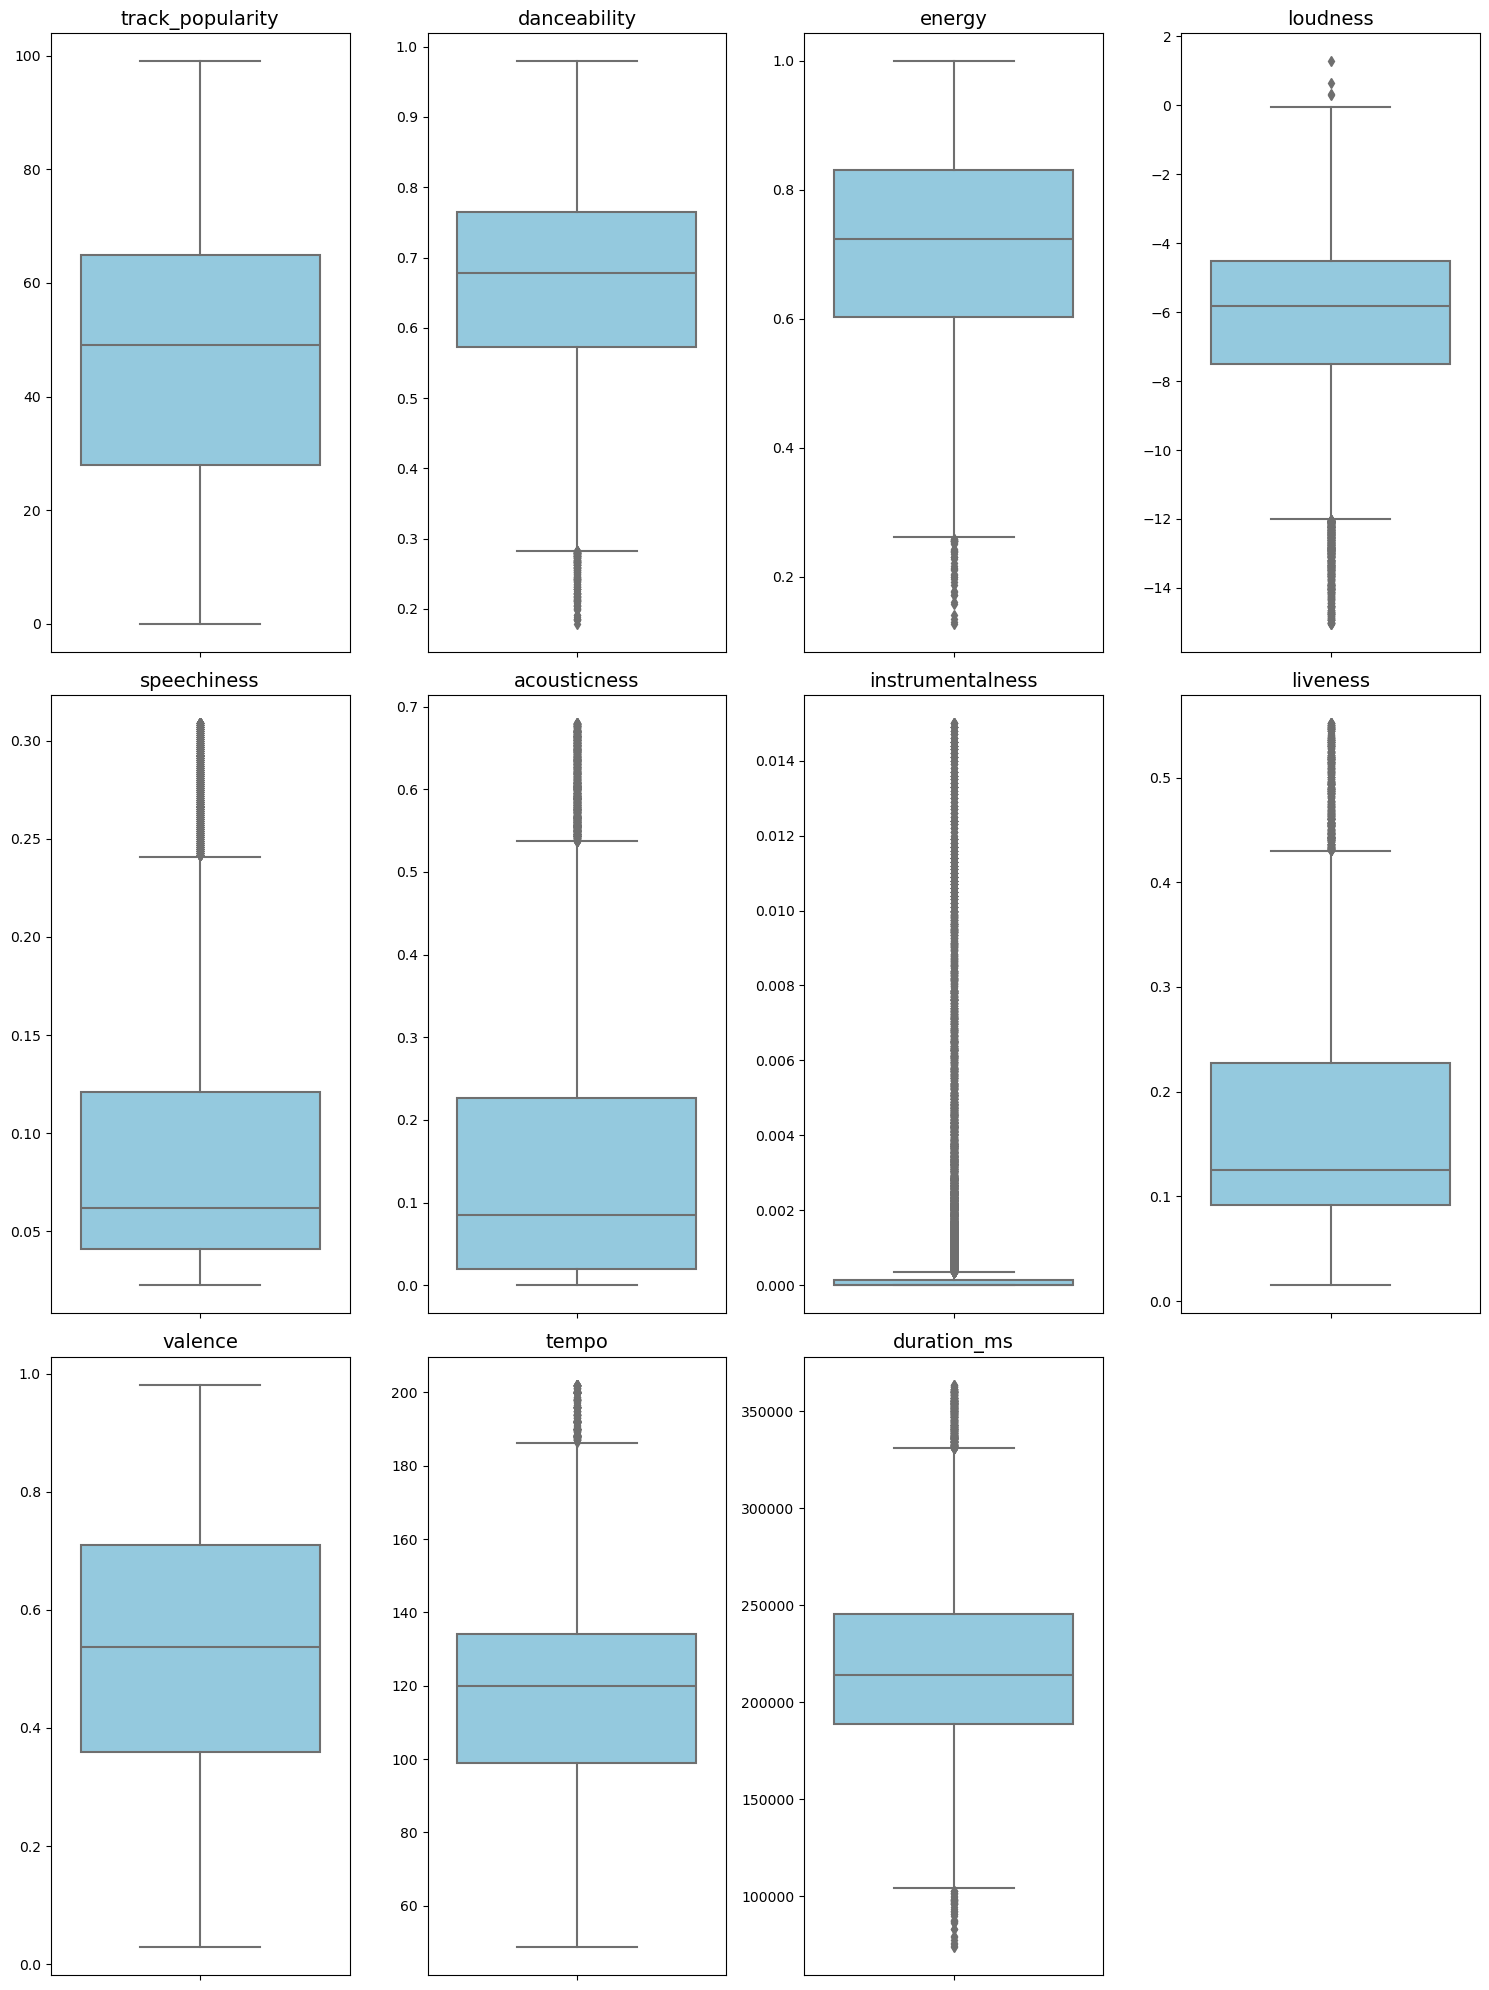

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(15, 5 * 4))
axes = axes.flatten() # Transforme la grille en liste simple pour la boucle

# 3. Boucle de création
for i, col in enumerate(quant_cols):
    sns.boxplot(y=songs[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=14)
    axes[i].set_ylabel('')

# 4. Nettoyage : supprimer les cases vides s'il y en a
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

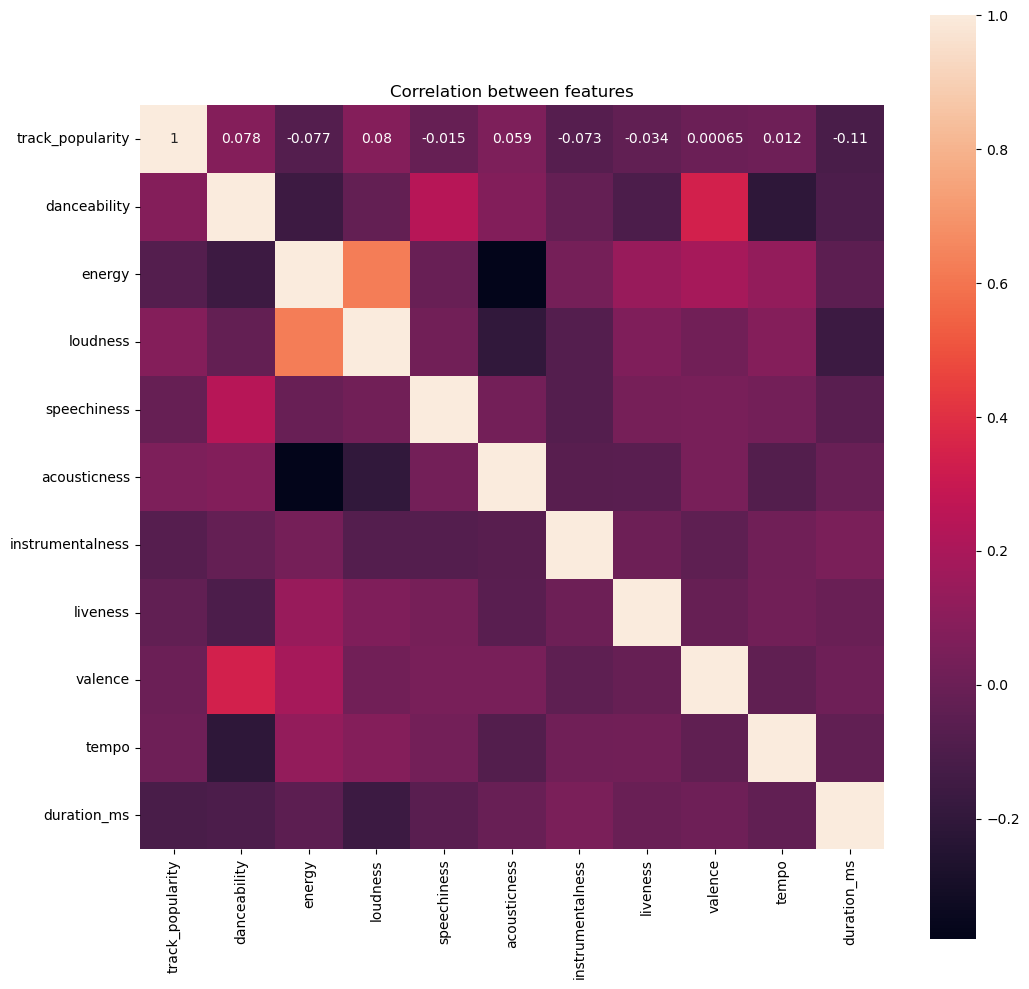

In [17]:
corr = songs.corr(numeric_only=True)

plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, square=True, cmap='rocket')
plt.title('Correlation between features')
plt.show()  

PCA

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

X=scale(songs[quant_cols])
print(len(quant_cols))

11


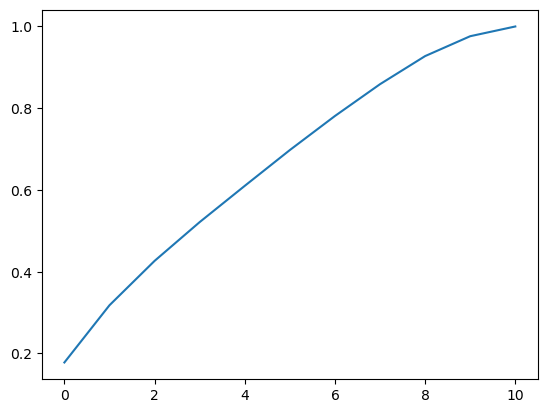

In [19]:
pca = PCA()
## Estimation, calcul des composantes principales
C = pca.fit(X).transform(X)
## Décroissance de la variance expliquée
plt.plot(pca.explained_variance_ratio_.cumsum())
plt.show()

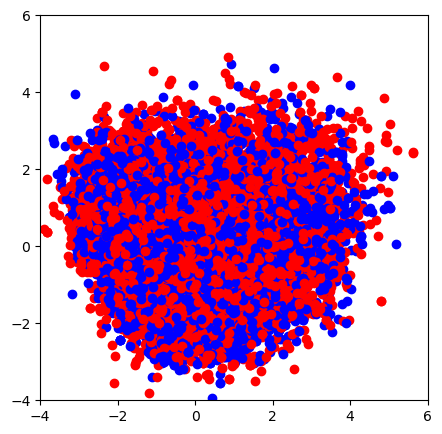

In [ ]:
plt.figure(figsize=(5,5))
for i, j, nom in zip(C[:,0], C[:,1], songs["mode"]):
    color = "red" if nom  else "blue"
    plt.plot(i, j, "o",color=color)
plt.axis((-4,6,-4,6))  
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 800x800 with 0 Axes>

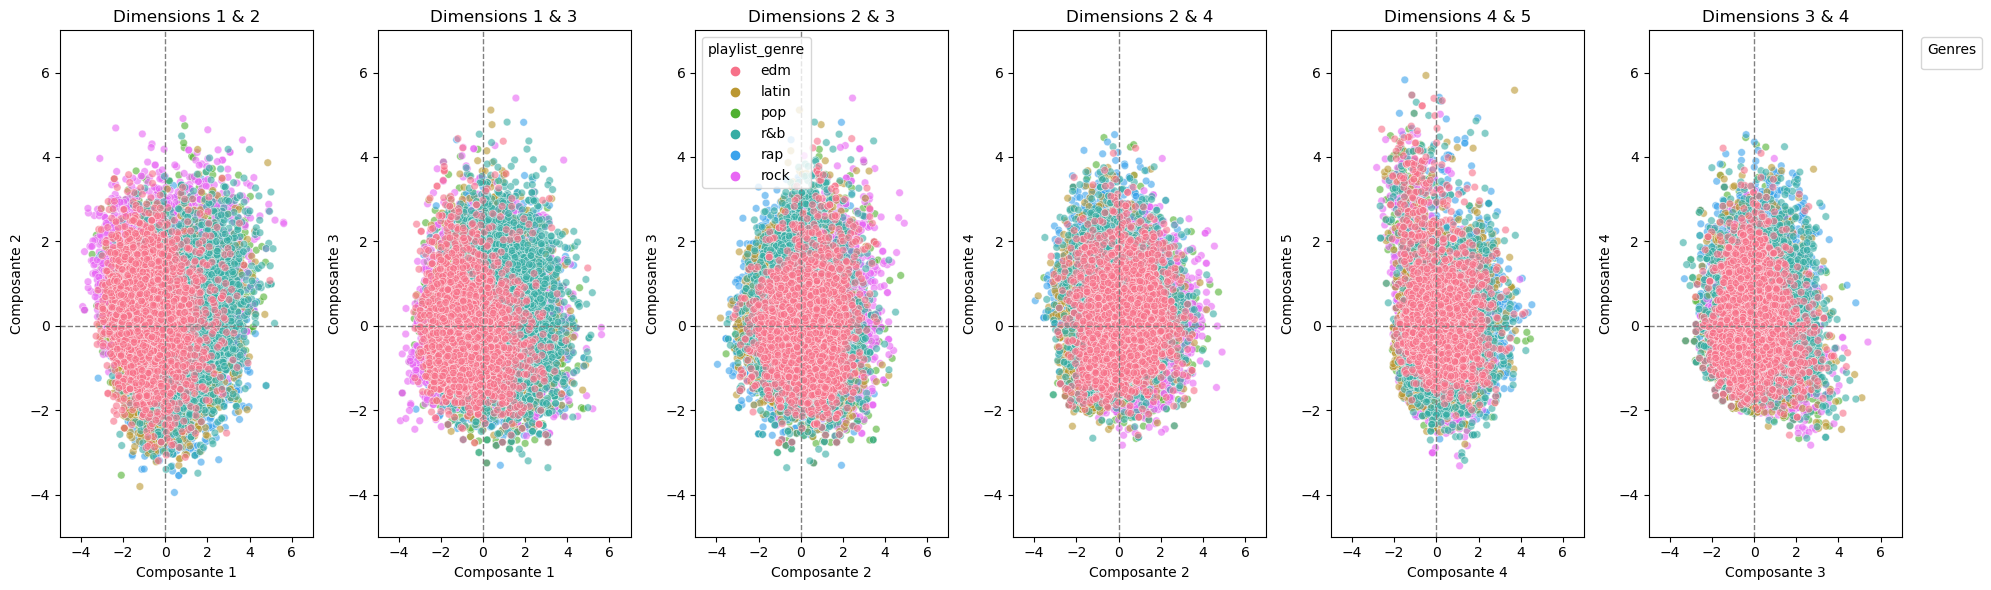

In [21]:
# On crée la figure
plt.figure(figsize=(8, 8))

# Liste des couples de dimensions à tester (index des colonnes de C)
couples = [(0, 1), (0, 2), (1, 2),(1,3),(3,4),(2,3)]

# Configuration de la figure (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 6, figsize=(20, 6))

for i, (dim_x, dim_y) in enumerate(couples):
    # Utilisation de Seaborn pour la simplicité et la gestion auto de la légende
    sns.scatterplot(
        x=C[:, dim_x], 
        y=C[:, dim_y], 
        hue=songs["playlist_genre"], 
        ax=axes[i],
        palette="husl",
        alpha=0.6,
        s=30,
        legend=(i == 2) # On n'affiche la légende que sur le dernier graphique
    )
    
    axes[i].set_title(f"Dimensions {dim_x+1} & {dim_y+1}")
    axes[i].set_xlabel(f"Composante {dim_x+1}")
    axes[i].set_ylabel(f"Composante {dim_y+1}")
    axes[i].axis((-5, 7, -5, 7)) # Ajuste selon tes données
    axes[i].axhline(0, color='grey', lw=1, ls='--')
    axes[i].axvline(0, color='grey', lw=1, ls='--')

# Placer la légende à l'extérieur à droite
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

[]

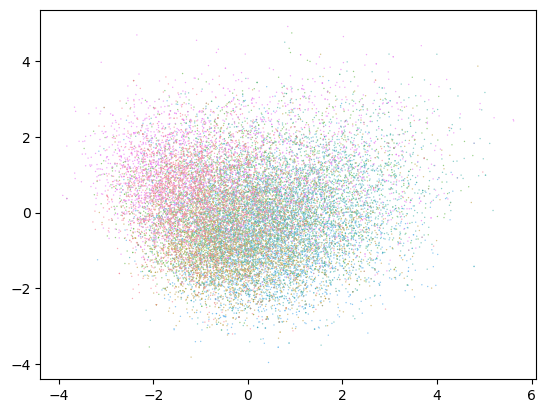

In [22]:
sns.scatterplot(
        x=C[:, 0], 
        y=C[:, 1], 
        hue=songs["playlist_genre"], 
        palette="husl",
        alpha=0.6,
        s=1,
        legend=(i == 2) # On n'affiche la légende que sur le dernier graphique
    )
plt.plot()

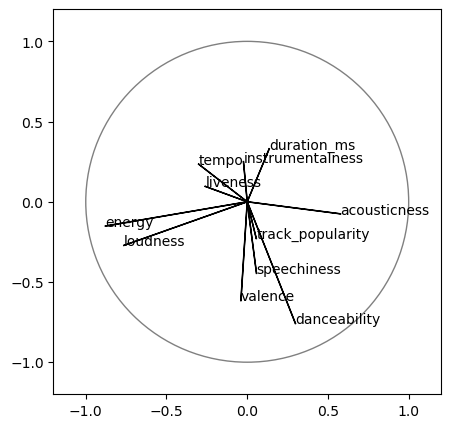

In [23]:
coord1=pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord2=pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1,coord2, songs[quant_cols].columns):
    plt.text(i, j, nom)
    plt.arrow(0,0,i,j,color='black')
plt.axis((-1.2,1.2,-1.2,1.2))
# cercle
c=plt.Circle((0,0), radius=1, color='gray', fill=False)
ax.add_patch(c)
plt.show()

In [24]:
from sklearn.cluster  import  KMeans
from  sklearn.metrics  import confusion_matrix
clust=KMeans(n_clusters=8)
clust.fit(X)
classe=clust.labels_
print(classe)

[3 1 3 ... 0 1 0]


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


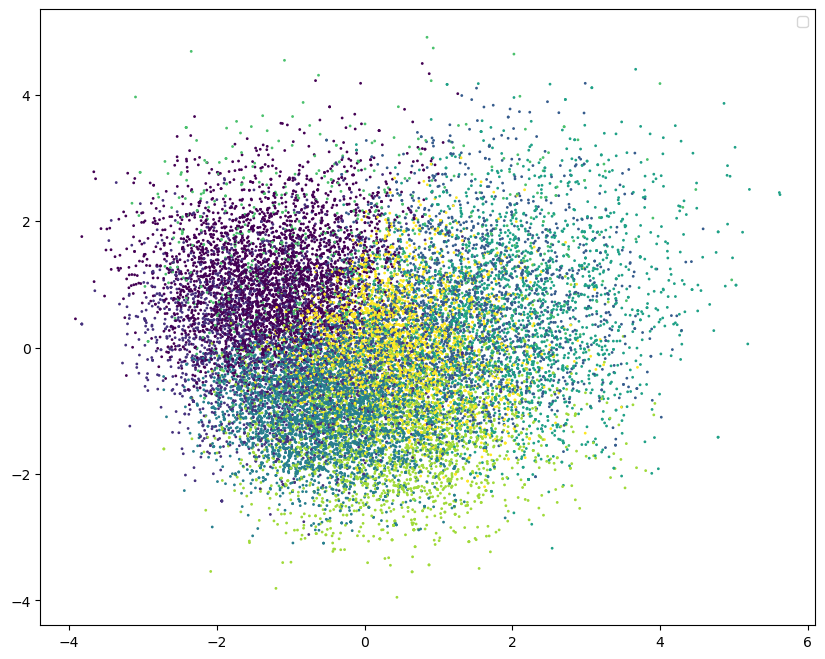

In [25]:
## Repésentation des individus dans les coordonnées de l'acp.
plt.figure(figsize=(10,8))
plt.scatter(C[:,0], C[:,1], c=classe, s=1) 
plt.legend()
plt.show()

Modification des variables

In [28]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

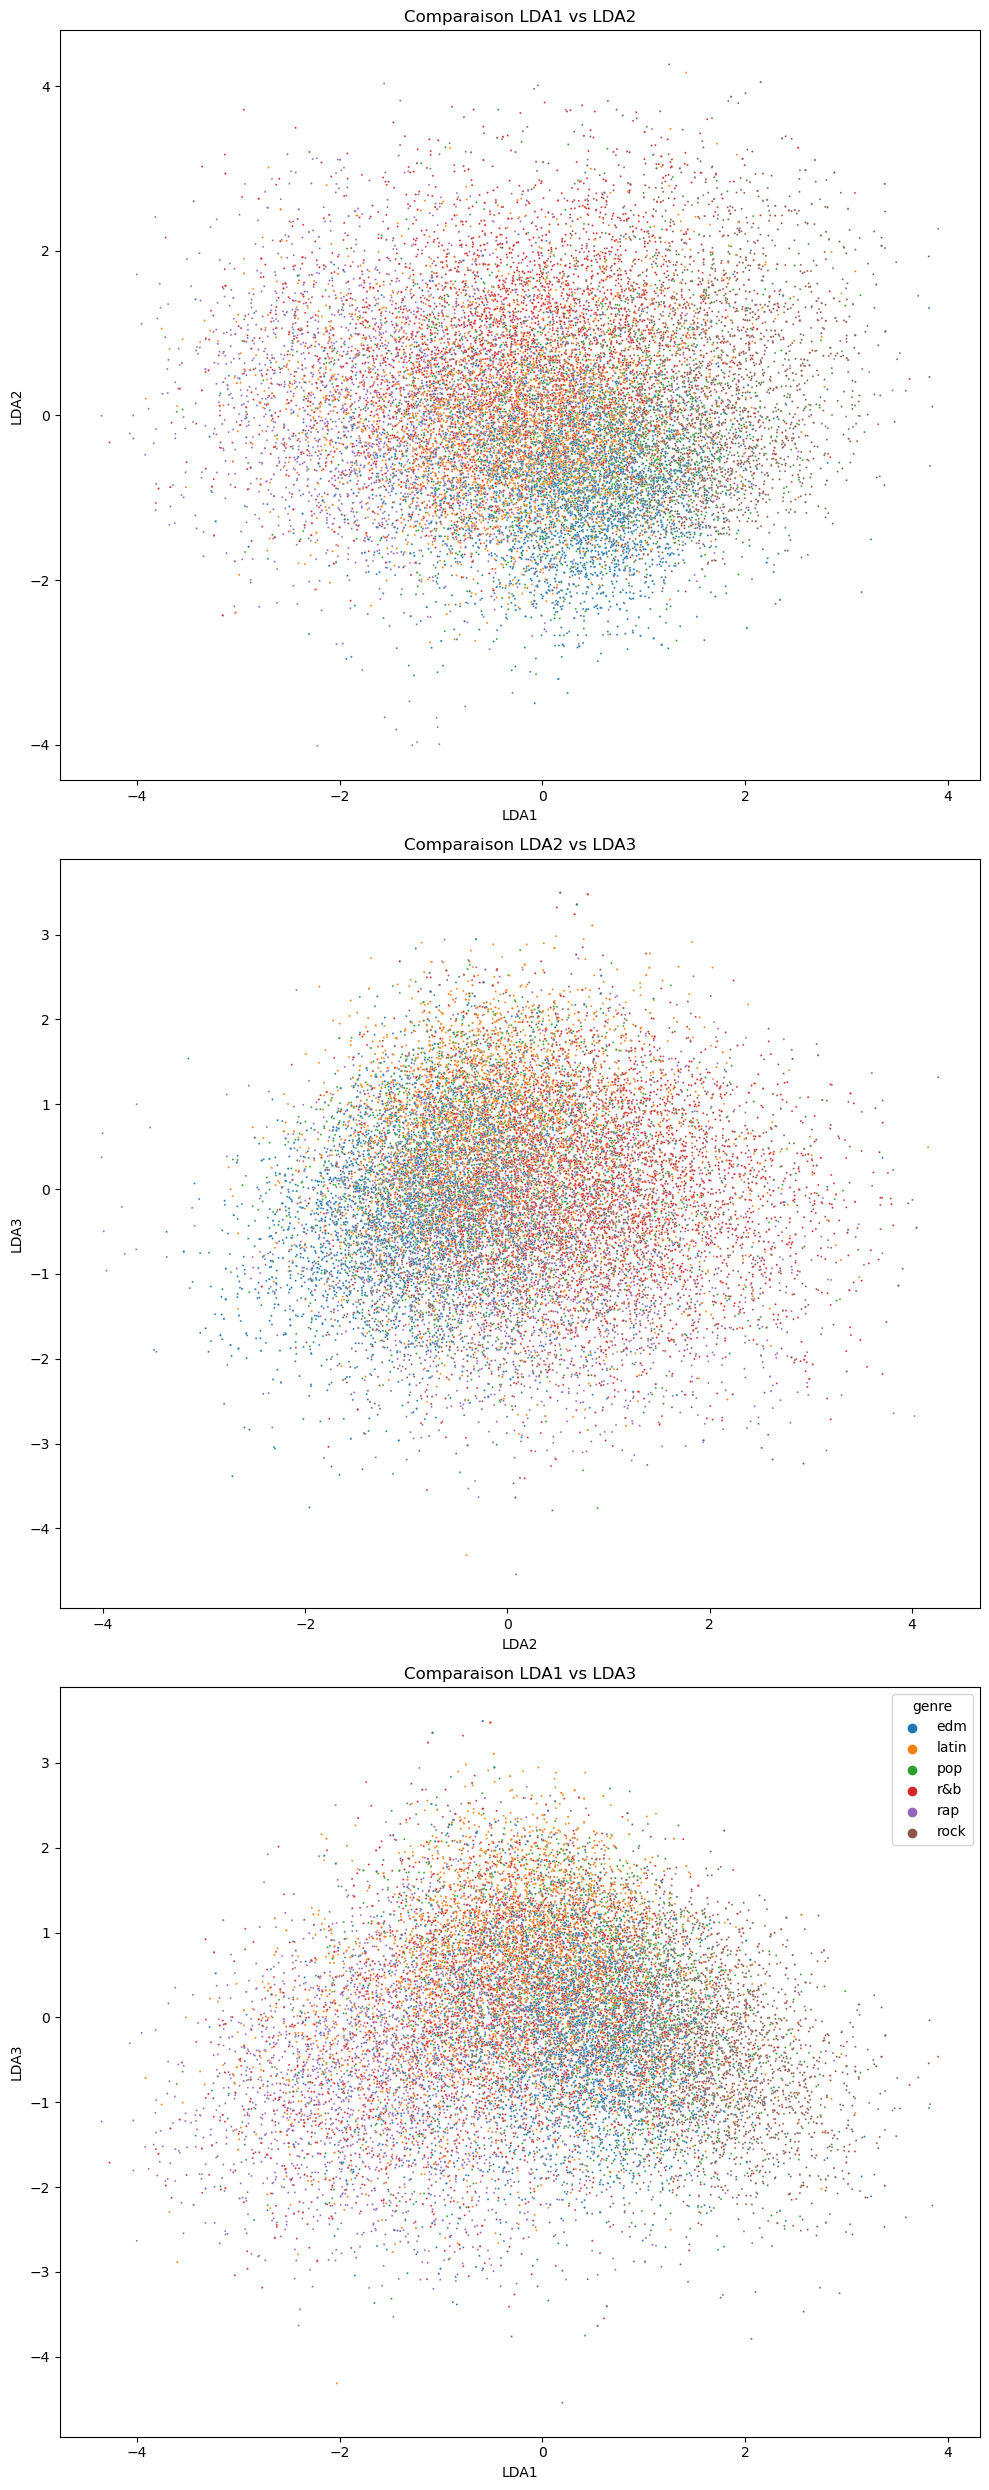

In [67]:
# 1. Calcul de toutes les dimensions possibles
# Le max est (nombre de genres - 1)
n_genres = songs['playlist_genre'].nunique()
max_dim = n_genres - 1

lda = LinearDiscriminantAnalysis(n_components=max_dim)
X_lda = lda.fit_transform(X, songs['playlist_genre'])

# 2. Création du tableau complet (Toutes les LD)
lda_columns = [f'LDA{i+1}' for i in range(max_dim)]
df_total = pd.DataFrame(X_lda, columns=lda_columns)
df_total['genre'] = songs['playlist_genre'].values

# 3. Affichage des 3 graphiques de comparaison
fig, axes = plt.subplots(3, 1, figsize=(10, 25))

# Liste des combinaisons (Axe X, Axe Y)
combos = [('LDA1', 'LDA2'), ('LDA2', 'LDA3'), ('LDA1', 'LDA3')]

for i, (ax_x, ax_y) in enumerate(combos):
    sns.scatterplot(ax=axes[i], data=df_total, x=ax_x, y=ax_y, hue='genre', alpha=1, s=2)
    axes[i].set_title(f'Comparaison {ax_x} vs {ax_y}')
    if i < 2: axes[i].get_legend().remove() # On garde la légende uniquement sur le dernier

plt.tight_layout()
plt.show()

/tmp/ipykernel_4903/2031079325.py:24: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



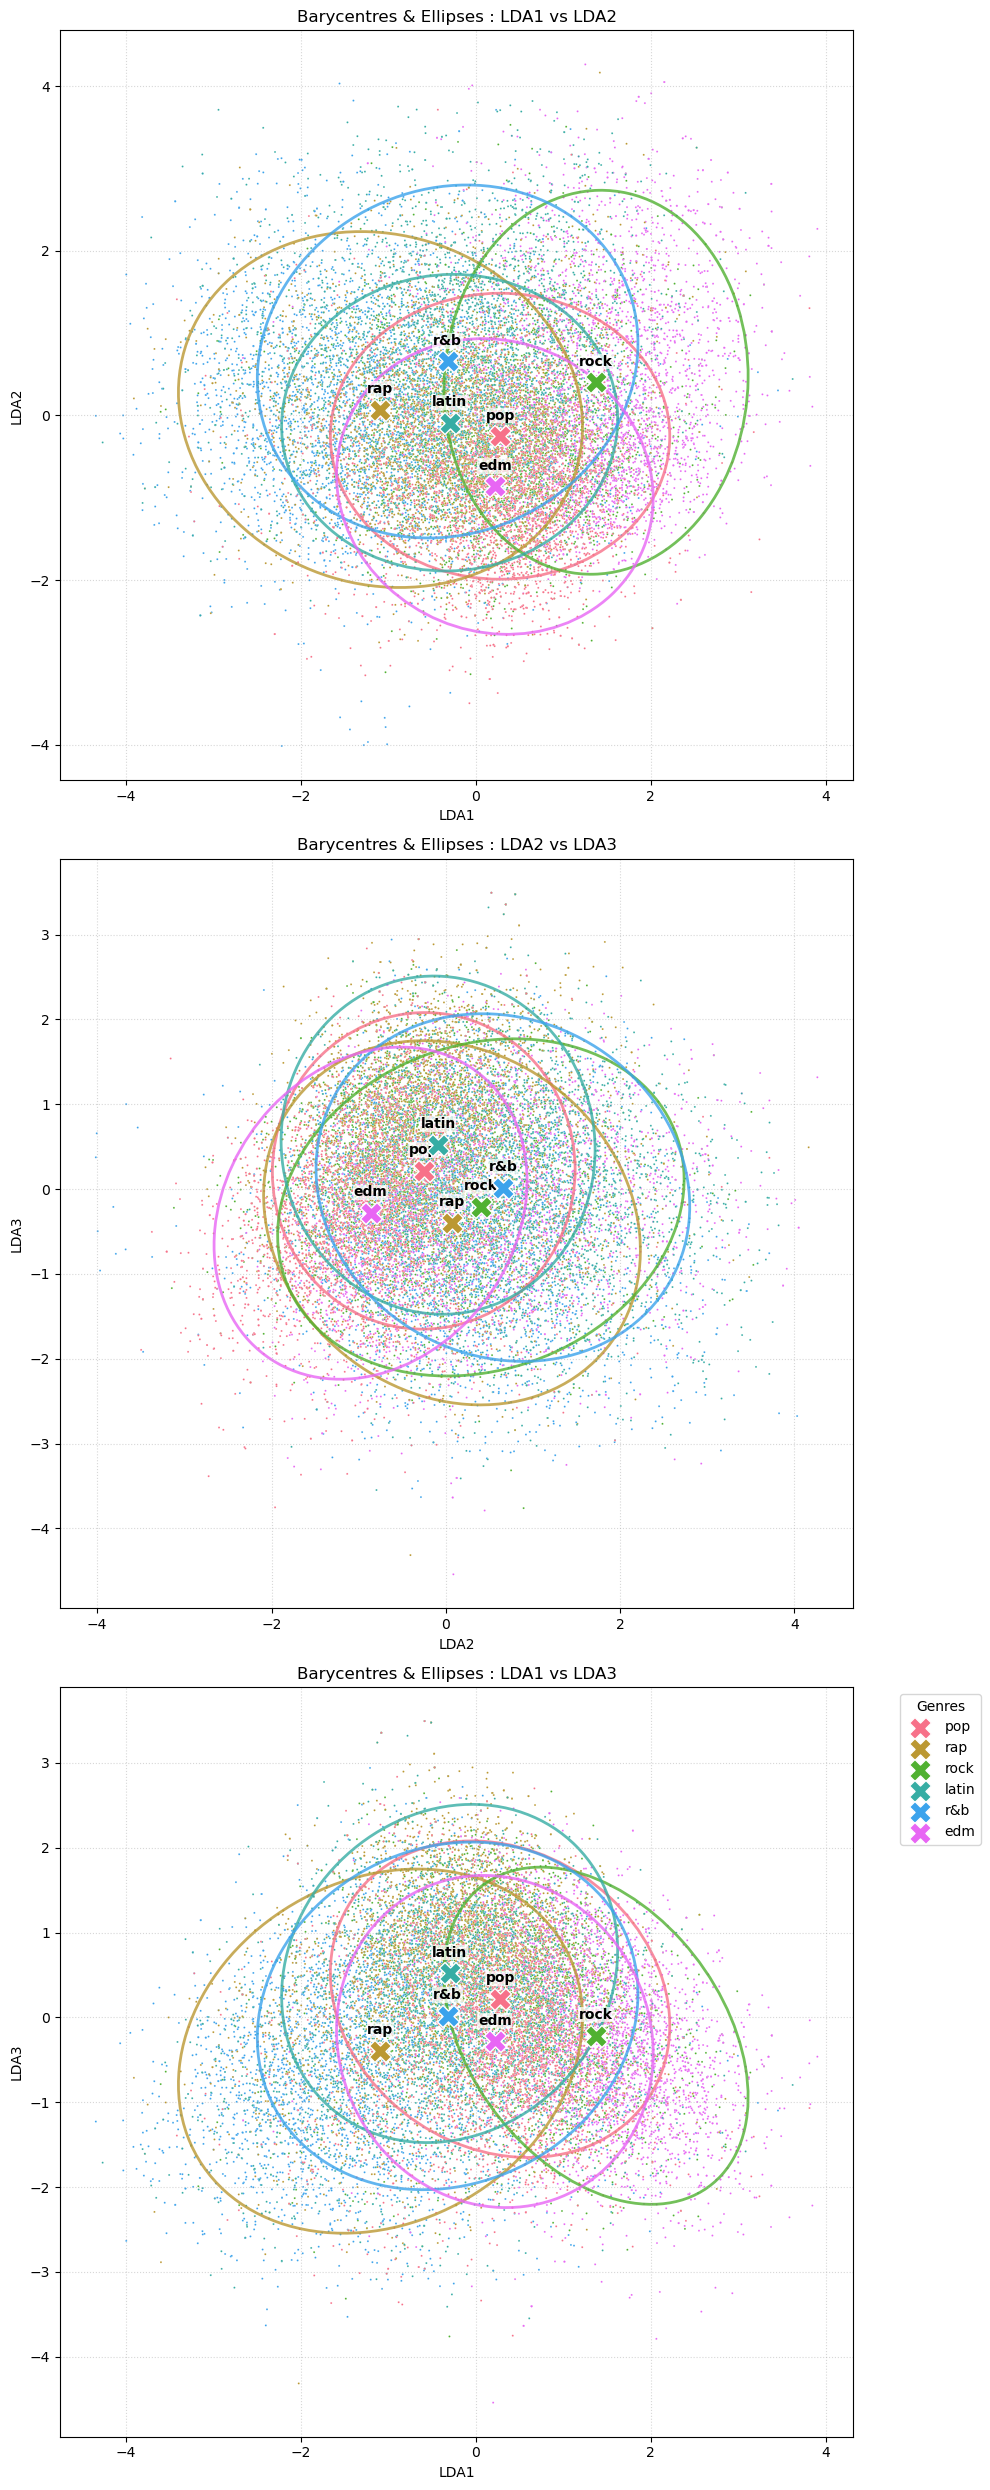

In [62]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import numpy as np
# --- Fonction pour les ellipses (inchangée) ---
def add_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, facecolor='none', **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(np.mean(x), np.mean(y))
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# --- Préparation des graphiques ---
fig, axes = plt.subplots(3, 1, figsize=(10, 25))
combos = [('LDA1', 'LDA2'), ('LDA2', 'LDA3'), ('LDA1', 'LDA3')]
genres = df_total['genre'].unique()
colors = sns.color_palette('husl', n_colors=len(genres))

# Calcul des barycentres pour chaque genre
barycentres = df_total.groupby('genre').mean()

for i, (ax_x, ax_y) in enumerate(combos):
    ax = axes[i]
    
    # 1. Tracer les points (très légers)
    sns.scatterplot(data=df_total, x=ax_x, y=ax_y, hue='genre', palette=colors, 
                    alpha=1, s=2, ax=ax, legend=False)

    for j, genre in enumerate(genres):
        subset = df_total[df_total['genre'] == genre]
        
        # 2. Tracer l'ellipse
        add_confidence_ellipse(subset[ax_x], subset[ax_y], ax=ax, 
                               edgecolor=colors[j], linewidth=2, alpha=0.8)
        
        # 3. Tracer le BARYCENTRE (le centre de gravité)
        # On utilise une croix 'X' ou un gros point 'o'
        ax.scatter(barycentres.loc[genre, ax_x], barycentres.loc[genre, ax_y], 
                   color=colors[j], s=250, marker='X', edgecolors='white', 
                   linewidth=1, zorder=10, label=genre if i == 2 else None)
        
        # 4. Ajouter le texte du genre à côté du barycentre
        ax.text(barycentres.loc[genre, ax_x], barycentres.loc[genre, ax_y] + 0.2, 
                genre, fontsize=10, weight='bold', ha='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

    ax.set_title(f'Barycentres & Ellipses : {ax_x} vs {ax_y}')
    ax.grid(True, linestyle=':', alpha=0.5)

# Légende sur le dernier graphique
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

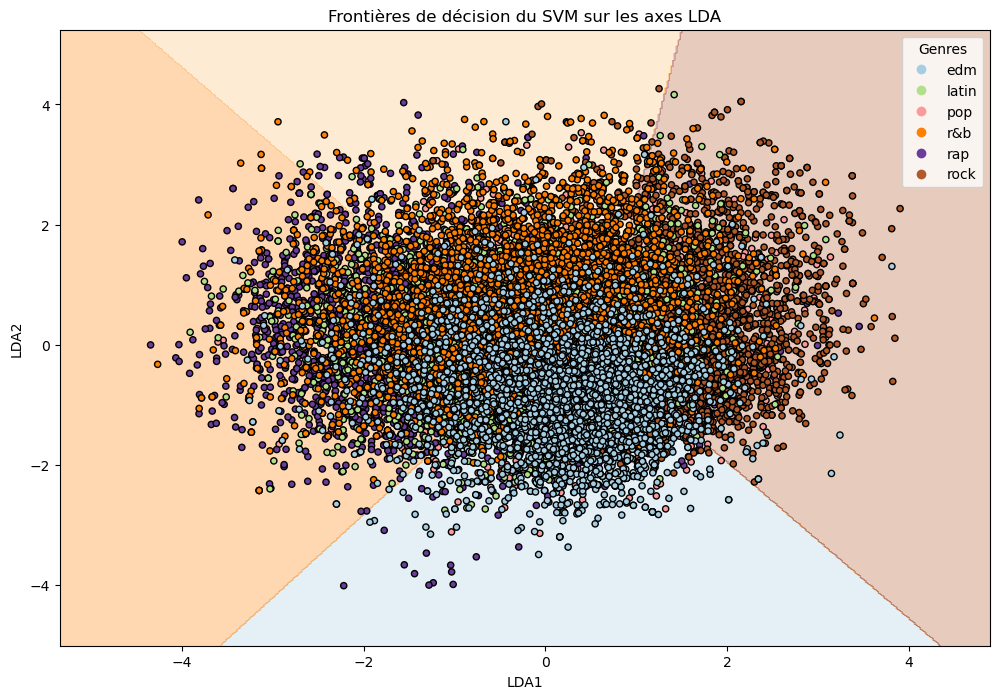

In [ ]:
from sklearn import svm
from sklearn.preprocessing import LabelEncoder

# 1. Préparation des données (on utilise les 2 premiers axes LDA)
X_svm = df_total[['LDA1', 'LDA2']].values
y = songs['playlist_genre']

# On encode les genres en nombres pour le tracé
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Création et entraînement du SVM (Noyau linéaire pour voir des lignes droites)
clf = svm.SVC(kernel='linear', C=1.0)
clf.fit(X_svm, y_encoded)

# 3. Création d'un maillage (mesh grid) pour dessiner les frontières
h = .02  # taille du pas dans le maillage
x_min, x_max = X_svm[:, 0].min() - 1, X_svm[:, 0].max() + 1
y_min, y_max = X_svm[:, 1].min() - 1, X_svm[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Prédiction sur tout le maillage
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)



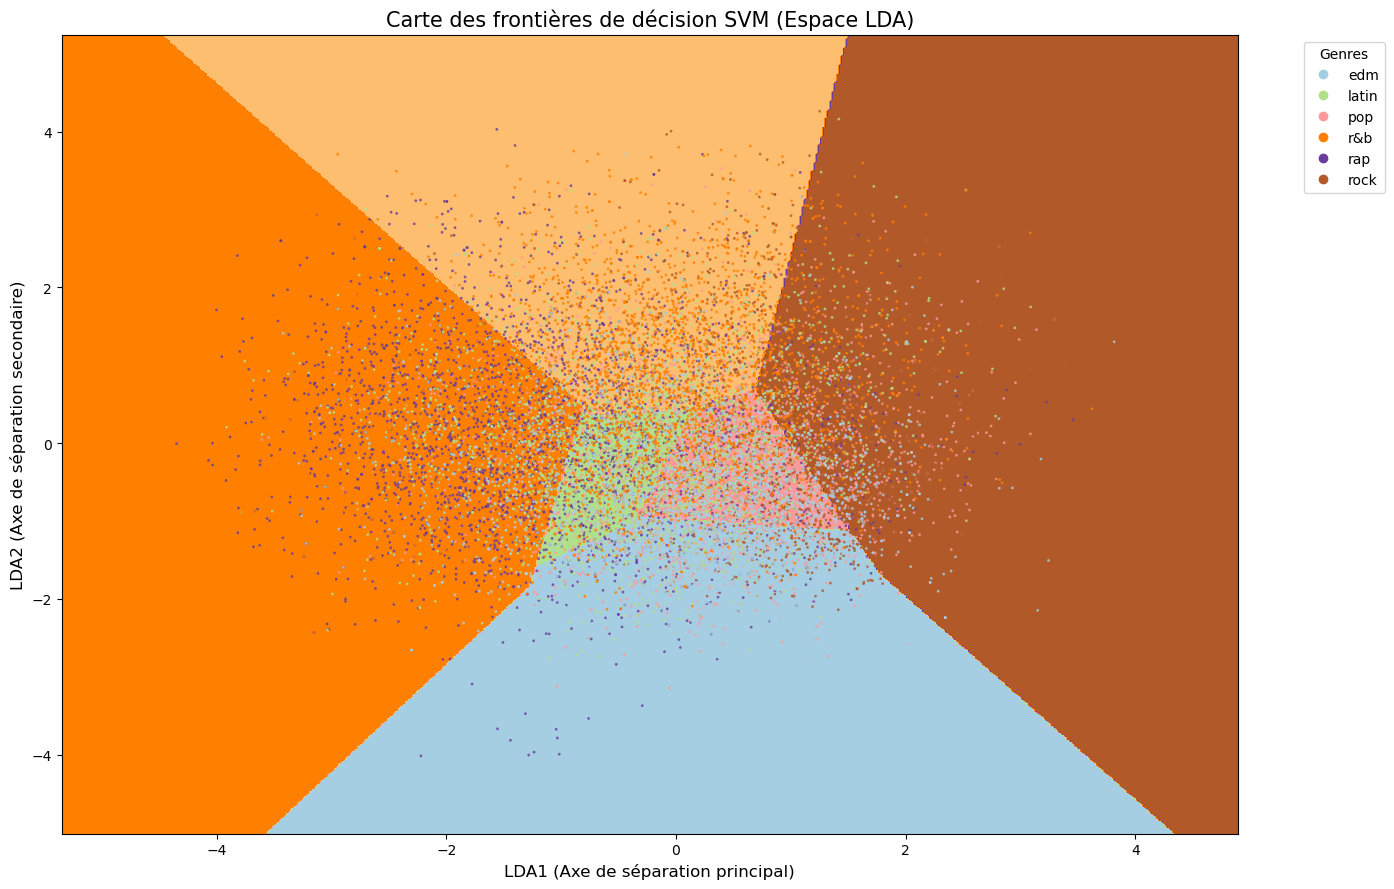

In [82]:
plt.figure(figsize=(14, 9))

# Zones de décision opaques (alpha=1)
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=1) 

# On affiche les points réels : très petits (s=2), sans bordures (lw=0)
# On utilise le même cmap pour que les points "fondent" dans leur zone
plt.scatter(
    X_svm[:, 0], 
    X_svm[:, 1], 
    c=y_encoded, 
    cmap=plt.cm.Paired, 
    s=4, 
    linewidths=0, 
    alpha=0.8
)

# Cosmétique du graphique
plt.title("Carte des frontières de décision SVM (Espace LDA)", fontsize=15)
plt.xlabel('LDA1 (Axe de séparation principal)', fontsize=12)
plt.ylabel('LDA2 (Axe de séparation secondaire)', fontsize=12)

# Ajout de la légende propre
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=list(le.classes_), title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
y_pred = clf.predict(X_svm)

In [89]:
# 1. Calcul de la matrice

cm = confusion_matrix(y_encoded, y_pred)

# 2. Calcul des métriques (TVP et TFP)
# TVP (Rappel) = diag / somme des lignes
tvp = cm.diagonal() / cm.sum(axis=1)

# TFP = Faux Positifs / (Faux Positifs + Vrais Négatifs)
# Soit : somme de la colonne (sans la diag) / somme de tout ce qui n'est pas la ligne réelle
tfp = []
for i in range(len(cm)):
    fp = cm[:, i].sum() - cm[i, i]
    vn = cm.sum() - cm[i, :].sum() - fp
    tfp.append(fp / (fp + vn))
# 4. Tableau des résultats
stats_df = pd.DataFrame({
    'Genre': le.classes_,
    'Taux Vrais Positifs (TVP)': [f"{v*100:.2f}%" for v in tvp],
    'Taux Faux Positifs (TFP)': [f"{v*100:.2f}%" for v in tfp]
}).set_index('Genre')

print("\n--- Analyse TVP (Sensibilité) vs TFP (Fausse Alerte) ---")
print(stats_df)


--- Analyse TVP (Sensibilité) vs TFP (Fausse Alerte) ---
      Taux Vrais Positifs (TVP) Taux Faux Positifs (TFP)
Genre                                                   
edm                      39.76%                    8.82%
latin                    21.58%                   10.88%
pop                      32.62%                   17.87%
r&b                      38.85%                   11.77%
rap                      49.33%                   12.34%
rock                     64.94%                   10.16%


In [90]:
# 1. On prépare le DataFrame avec les noms de genres
df_cm_styled = pd.DataFrame(
    cm, 
    index=le.classes_, 
    columns=le.classes_
)

# 2. On applique un style "Heatmap" directement sur le tableau Pandas
# Cela fonctionne parfaitement dans Jupyter, Colab ou VS Code
styled_matrix = df_cm_styled.style.background_gradient(cmap='Blues') \
    .set_properties(**{'text-align': 'center', 'font-weight': 'bold', 'border': '1px solid black'}) \
    .set_caption("MATRICE DE CONFUSION (Réel en ligne / Prédit en colonne)")

# 3. Affichage du tableau de stats avec des couleurs pour TVP et TFP
# On recalcule les taux proprement (en float pour le style)
tvp_float = cm.diagonal() / cm.sum(axis=1)
tfp_float = []
for i in range(len(cm)):
    fp = cm[:, i].sum() - cm[i, i]
    vn = cm.sum() - cm[i, :].sum() - fp
    tfp_float.append(fp / (fp + vn) if (fp + vn) > 0 else 0)

df_stats_styled = pd.DataFrame({
    'TVP (Vrais Positifs)': tvp_float,
    'TFP (Faux Positifs)': tfp_float
}, index=le.classes_)

# On affiche les deux
display(styled_matrix)
display(df_stats_styled.style.background_gradient(cmap='RdYlGn_r', subset=['TFP (Faux Positifs)']) \
                             .background_gradient(cmap='RdYlGn', subset=['TVP (Vrais Positifs)']) \
                             .format("{:.2%}"))

,edm,latin,pop,r&b,rap,rock
edm,1205,314,836,145,263,268
latin,415,845,1010,577,795,274
pop,617,605,1331,407,360,760
r&b,125,454,481,1444,782,431
rap,262,487,318,613,1760,128
rock,218,62,484,362,23,2128


,TVP (Vrais Positifs),TFP (Faux Positifs)
edm,39.76%,8.82%
latin,21.58%,10.88%
pop,32.62%,17.87%
r&b,38.85%,11.77%
rap,49.33%,12.34%
rock,64.94%,10.16%
